### this notebook is being written with the intention of postprocessing and generating figures from the outputs of trackastra 070826

In [1]:
import os
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import tifffile
import napari
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob
from matplotlib.patches import Patch


In [2]:
# old code used to compare output of cell segmentation 
# proabbly don't need this anymore 
def compare_masks(old_kymo, new_kymo, phase_kymo):
    tab20_cmap = plt.get_cmap("tab20")
    colored_mask_old = np.zeros((*old_kymo.shape, 4), dtype=np.float32)  
    unique_labels = np.unique(old_kymo)
    for label in unique_labels:
        if label > 0: 
            mask_indices = (old_kymo == label)
            colored_mask_old[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
            colored_mask_old[mask_indices, 3] = 1.0 
    colored_mask_new = np.zeros((*new_kymo.shape, 4), dtype=np.float32)  
    unique_labels = np.unique(new_kymo)
    for label in unique_labels:
        if label > 0: 
            mask_indices = (new_kymo == label)
            colored_mask_new[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
            colored_mask_new[mask_indices, 3] = 1.0 
    
    plt.figure(figsize=(60, 20))

    plt.subplot(1, 2, 2)
    plt.imshow(phase_kymo, cmap='gray')  
    plt.imshow(colored_mask_old, alpha=0.5)  
    plt.title(f'Mask old')
    plt.axis('off')

    plt.show()

    plt.figure(figsize=(60, 20))

    plt.subplot(1, 2, 2)
    plt.imshow(phase_kymo, cmap='gray')  
    plt.imshow(colored_mask_new, alpha=0.5)  
    plt.title(f'Mask new')
    plt.axis('off')

    plt.show()   
    
    


In [3]:
# code needed to help trim tif stacks
def get_tiff_frame_count(file_path):
	"""
	Reads a TIFF file using imread and returns the index of the last time frame (T - 1).
	NOTE: This loads the entire file into memory.
	"""
	try:
		# Load the entire image stack into memory
		img_stack = tifffile.imread(file_path)

		shape = img_stack.shape

		# Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1
			return shape[0] - 1
		else:
			# Single 2D image
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0

def stack_to_kymograph(stack):
    """
    takes a numpyarray of an image in the format (t, y, x) and converts it into a kymograph
    """

    kymograph_gray = []
    for i in range(stack.shape[0]):
        frame = stack[i]
        if frame.ndim == 3:
            kymograph_gray.append(frame, axis=2)
        else:
            kymograph_gray.append(frame)
    
    kymograph = np.concatenate(kymograph_gray, axis =1)
    return kymograph

In [4]:
# where kymograph gets plotted 
# requires fluor to match the phase and tracks correct frame trimming 
def plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph, fluor=None):
    t, y, x = imgs.shape

    # Transpose to (y, t, x) then reshape to (y, t*x)
    kymo_imgs = imgs.transpose(1, 0, 2).reshape(y, -1)  # (400, 540)
    kymo_masks = ctc_masks.transpose(1, 0, 2).reshape(y, -1)

    kymo_tracks = napari_tracks.copy()
    # New x position: time_frame * width + original_x
    new_x = napari_tracks[:, 1] * x + napari_tracks[:, 3]
    kymo_tracks = np.column_stack([
        napari_tracks[:, 0],  # track_id
        np.zeros(len(napari_tracks)),  # dummy time (all in same frame)
        napari_tracks[:, 2],  # y stays the same
        new_x  # new x position
    ])

    v = napari.Viewer()
    v.add_image(kymo_imgs, name='kymograph')
    if fluor is not None:
        kymo_fluor = fluor.transpose(1, 0, 2).reshape(y, -1)
        v.add_image(kymo_fluor, name='fluor_kymo')   # plain grayscale layer
    v.add_labels(kymo_masks, name='masks_kymo')
    v.add_tracks(data=kymo_tracks, graph=napari_tracks_graph, name='tracks_kymo')



In [5]:
### base paths:
time_dict_path = '/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/data/time_dict_070826.json'

with open(time_dict_path) as f:
    time_dict = json.load(f)   # {exp: {fov: {peak: {'start': int, 'end': int|None}}}}

base_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data'
track_astra_output = '/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output'
output = os.path.join(track_astra_output, 'trackastra_extraction_test')

phase_c = '0'
fluor_c = '1'
exp = 'DUMM_giTG059_068_SC_093025'
fov = '015'
peak_id = '228'

In [6]:
subtracted_dir = os.path.join(base_dir, exp, 'hyperstacked', 'drift_corrected',
'rotated', 'mm_channels', 'subtracted')

phase_path = os.path.join(
            subtracted_dir, f'subtracted_FOV_{fov}_region_{peak_id}_c_{phase_c}.tif')
fluor_path = os.path.join(
            subtracted_dir, f'subtracted_FOV_{fov}_region_{peak_id}_c_{fluor_c}.tif')
mask_path = os.path.join(
            subtracted_dir, 'napari_corrections', f'{fov}_{peak_id}_corrected.tif')
imgs_path = os.path.join(
            track_astra_output, f'{exp}_imgs_{fov}_{peak_id}.npy')
tracks_path = os.path.join(
            track_astra_output, f'{exp}_napari_tracks_{fov}_{peak_id}.npy')
ctc_path = os.path.join(
            track_astra_output, f'{exp}_ctc_masks_{fov}_{peak_id}.npy')
graph_path = os.path.join(
            track_astra_output, f'{exp}_napari_tracks_graph_{fov}_{peak_id}.json')

In [7]:
# load all the correct data assumes stored in format shown above 

imgs = np.load(imgs_path)
napari_tracks = np.load(tracks_path)
ctc_masks = np.load(ctc_path)


with open(graph_path) as f:
    napari_tracks_graph = json.load(f)
# (optional) convert keys/values back to int if needed:
napari_tracks_graph = {int(k): int(v) for k, v in napari_tracks_graph.items()}

fluor = tifffile.imread(fluor_path)
start = time_dict[exp][fov][peak_id]['start']
n_frames = imgs.shape[0]
if n_frames is not None:
    end = start + n_frames
else:
    end = time_dict[exp][fov][peak_id].get('end')
    if end is None:
        end = get_tiff_frame_count(peak_id)   # T-1, matches trackastra trimming
fluor_trimmed = fluor[start:end]
if n_frames is not None and fluor_trimmed.shape[0] != n_frames:
    print(f"WARNING: fluor trimmed to {fluor_trimmed.shape[0]} frames, expected {n_frames} "
            f"({exp}/{fov}/{peak_id}) - layers may not align.")


In [8]:
plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph, fluor_trimmed)

/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


### code to begin looking at outputs of trackastra extraction

In [9]:
def detect_fluorescence_bursts_by_group(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The number of standard deviations above the
                                   mean to be considered a significant burst.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (std_dev_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

def merge_dicts(dict1, dict2):
    merged = defaultdict(dict)
    
    for key in dict1.keys():
        if key in dict2:
            # Merge if key exists in both dictionaries
            for subkey, values in dict1[key].items():
                if subkey in dict2[key]:
                    # Combine the lists for subkey
                    merged[key][subkey] = list(set(values + dict2[key][subkey]))
                else:
                    merged[key][subkey] = values
            for subkey, values in dict2[key].items():
                if subkey not in merged[key]:
                    merged[key][subkey] = values
        else:
            merged[key] = dict1[key]
    
    for key in dict2.keys():
        if key not in merged:
            merged[key] = dict2[key]
    
    return dict(merged)

In [10]:
strain_exp_dict = {
"chpS":{"DUMM_giTG62_Glucose_012925": ["005"],
        "DUMM_alkA_chpS_111325": ["003", "005", "006", "007", "009", "010", "011"]}, "baeS":{"DUMM_giTG66_Glucose_012325": ["003"]},  
"lacZ":{"DUMM_giTG059_noKan_Glucose_031125": ["004"],
        "DUMM_giTG059_060_061125": ["008"]},
"gfcE": {"DUMM_giTG064_Glucose_022625": ["001", "015"]},
"gldA": {"DUMM_giTG69_Glucose_013025": ["007"]},
"alkA": {"DUMM_giTG068_063_061725_v2": ["000"],
        "DUMM_giTG63_giTG67_Glucose_121724_1_v2": ["005"],
        "DUMM_alkA_chpS_111325": ["017","018","022", "023"]},
"mazF": {"DUMM_giTG059_060_061125": ["015"]}, 
"hupA":{"DUMM_giTG068_052925": ["005"], 
        "DUMM_giTG068_063_061725": ["012"]},
"araB": {"DUMM_CL008_giTG061_081225": ["015", "016", "017", "018", "019", "020"]},
}

strain_exp_dict_2 = {
  "chpS": {
    "DUMM_giTG062_064_121325": ["005", "010", "012"]
  },
  "baeS": {
    "DUMM_gitg068_baeS_100225": ["013", "017", "018", "019", "020", "021", "022", "023"],
    "DUMM_baeS_gfcE_112025": ["005"],
    "DUMM_giTG066_063_120925": ["002", "007"]
  },
  "gfcE": {
    "DUMM_baeS_gfcE_112025": ["011", "012", "016"],
    "DUMM_giTG062_064_121325": ["015", "019"],
    "DUMM_giTG060_064_121425": ["013", "014", "020", "022"]
  },
  "gldA": {
    "DUMM_giTG069_063_121125": ["013", "016", "022", "025"],
    "DUMM_giTG069_063_121225": ["013", "018", "022"]
  },
  "alkA": {
    "DUMM_giTG066_063_120925": ["018", "019"],
    "DUMM_giTG069_063_121125": ["001", "005", "006", "008"],
    "DUMM_giTG069_063_121225": ["000"]
  },
  "mazF": {
    "DUMM_giTG060_064_121425": ["000", "005"],
    "DUMM_mazF_murQ_121625": ["005", "006", "012"]
  },
  "murQ": {
    "DUMM_mazF_murQ_121625": ["016", "017", "018"]
  }
}

strain_exp_dict_3={
"lacZ":{"DUMM_giTG059_068_SC_093025": ["015", "020"]
    },
"araB": {"CL008_giTG068_072925": ["003", "007", "009"]
    }
}

minutes_interval = {"DUMM_giTG62_Glucose_012925":5,
"DUMM_giTG66_Glucose_012325":5,
"DUMM_giTG059_noKan_Glucose_031125":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG064_Glucose_022625":5,
"DUMM_giTG69_Glucose_013025":5,
"DUMM_giTG068_063_061725_v2":10,
"DUMM_giTG63_giTG67_Glucose_121724_1_v2":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG068_052925":5,
"DUMM_giTG068_063_061725":10,
"DUMM_CL008_giTG061_081225":10,
"DUMM_alkA_chpS_111325":10,
"DUMM_giTG062_064_121325":10,
"DUMM_gitg068_baeS_100225":10,
"DUMM_baeS_gfcE_112025":10,
"DUMM_giTG066_063_120925":10,
"DUMM_giTG060_064_121425":10,
"DUMM_giTG069_063_121125":10,
"DUMM_giTG069_063_121225":10,
"DUMM_mazF_murQ_121625":10,
"DUMM_giTG059_068_SC_093025":10,
"CL008_giTG068_072925":10
}

combined_dict1 = merge_dicts(strain_exp_dict, strain_exp_dict_2)
combined_dict = merge_dicts(combined_dict1, strain_exp_dict_3)



In [11]:
exposure_dict= {'CL008_giTG068_072925': [45, 150],
'DUMM_alkA_chpS_111325': [120, 150],
'DUMM_baeS_gfcE_112025': [120, 150],
'DUMM_CL008_giTG061_081225': [120, 150],
'DUMM_giTG059_060_061125': [250, 250],
'DUMM_giTG059_068_SC_093025': [120, 150],
'DUMM_giTG059_noKan_Glucose_031125': [250, 450],
'DUMM_giTG060_064_121425': [120, 150],
'DUMM_giTG062_064_121325': [120, 150],
'DUMM_giTG064_Glucose_022625': [250, 500],
'DUMM_giTG066_063_120925': [120, 150],
'DUMM_giTG068_052925': [250, 450],
'DUMM_giTG068_063_061725': [45, 150],
'DUMM_gitg068_baeS_100225': [120, 150],
'DUMM_giTG069_063_121125': [120, 150],
'DUMM_giTG069_063_121225': [120, 150],
'DUMM_giTG66_Glucose_012325': [250, 500],
'DUMM_giTG69_Glucose_013025': [250, 500],
'DUMM_mazF_murQ_121625': [120, 150],
'DUMM_giTG068_063_061725_v2': [45, 150],
'DUMM_giTG63_giTG67_Glucose_121724_1_v2': [250, 500],
'DUMM_giTG62_Glucose_012925': [250, 500]
}

In [ ]:
# # load data in and save as a file 
# # only run if loading data for the first time

# pkl_paths = sorted(glob.glob(os.path.join(base_dir, 'trackastra_cell_data_*.pkl')))
# print(f"Found {len(pkl_paths)} trackastra_cell_data pkls")

# all_data = pd.concat((pd.read_pickle(p) for p in pkl_paths), ignore_index=True)

# all_data['gene'] = None
# for gene, exps_fov in combined_dict.items():
#     for exp_view, fovs in exps_fov.items():
#         mask = all_data['FOV'].isin(fovs) & (all_data['experiment_name'] == exp_view)
#         all_data.loc[mask, 'gene'] = gene

# all_data.to_csv('/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/data/all_data_070926.csv', index=False)


In [ ]:
# load in data 

all_data = pd.read_csv('/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/data/all_data_070926.csv')


In [17]:
df_g = all_data.dropna(subset=['gene']).copy()

unmapped = sorted(set(all_data['experiment_name'].unique()) - set(df_g['experiment_name'].unique()))
if unmapped:
    print("WARNING: experiments with no gene mapping (excluded from per-gene stats):")
    for e in unmapped:
        print(f"  - {e}")

In [18]:
n_experiments_total = all_data['experiment_name'].nunique()

n_experiments = df_g.groupby('gene')['experiment_name'].nunique()
n_kymographs = df_g.groupby('gene').apply(
    lambda x: len(x[['experiment_name', 'FOV', 'trench_id']].drop_duplicates())
)
n_unique_cells = df_g.groupby('gene').apply(
    lambda x: len(x[['experiment_name', 'FOV', 'trench_id', 'track_id']].drop_duplicates())
)

summary = pd.DataFrame({
    'n_experiments': n_experiments,
    'n_kymographs': n_kymographs,
    'n_unique_cells': n_unique_cells,
}).sort_values('n_unique_cells', ascending=False)

print(f"Total experiments analyzed : {n_experiments_total}")
print(f"Total kymographs (peak_ids): {len(df_g[['experiment_name', 'FOV', 'trench_id']].drop_duplicates())}")
print(f"Total unique cells (tracks): {len(df_g[['experiment_name', 'FOV', 'trench_id', 'track_id']].drop_duplicates())}")
print("\nPer-gene summary:")
print(summary.to_string())

Total experiments analyzed : 18
Total kymographs (peak_ids): 235
Total unique cells (tracks): 10542

Per-gene summary:
      n_experiments  n_kymographs  n_unique_cells
gene                                             
baeS              3            53            2673
araB              2            36            1527
lacZ              3            23            1483
gfcE              4            29            1252
chpS              3            30            1250
alkA              4            22             802
gldA              3            19             781
mazF              3            13             521
murQ              1            10             253


/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_29408/486162329.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_kymographs = df_g.groupby('gene').apply(
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_29408/486162329.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_unique_cells = df_g.groupby('gene').apply(


In [19]:
df_bursts = detect_fluorescence_bursts_by_group(
    df_g,
    fluor_col='intensity_mean_fluor',
    rolling_window_size=10,
    std_dev_threshold=3,
)

bursts_per_gene = df_bursts.groupby('gene')['is_burst'].sum().sort_values(ascending=False)

      n_experiments  n_kymographs  n_unique_cells  n_bursts
gene                                                       
baeS              3            53            2673       139
araB              2            36            1527       134
lacZ              3            23            1483       156
gfcE              4            29            1252        78
chpS              3            30            1250        77
alkA              4            22             802        48
gldA              3            19             781        69
mazF              3            13             521        17
murQ              1            10             253        14


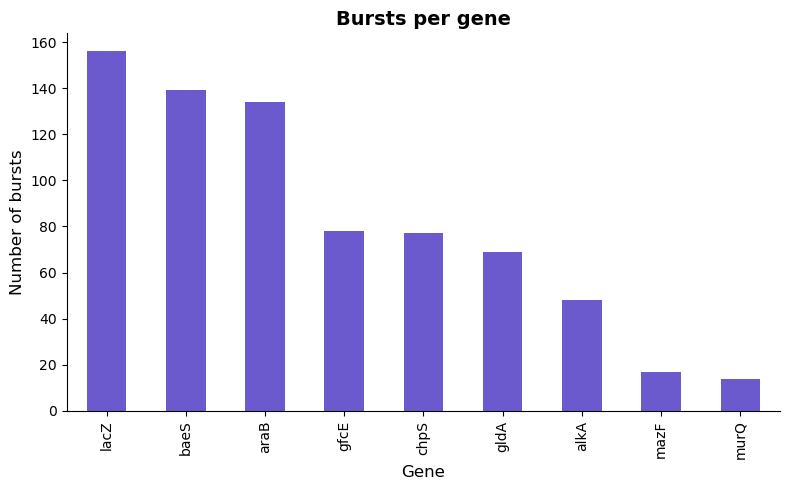

In [20]:
summary['n_bursts'] = bursts_per_gene
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
bursts_per_gene.plot.bar(ax=ax, color='slateblue')
ax.set_xlabel('Gene', fontsize=12)
ax.set_ylabel('Number of bursts', fontsize=12)
ax.set_title('Bursts per gene', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

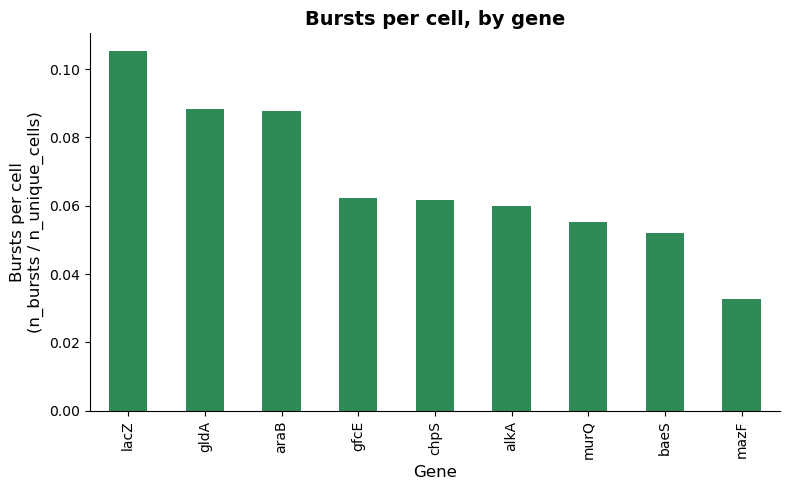

In [21]:
bursts_per_cell = (summary['n_bursts'] / summary['n_unique_cells']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bursts_per_cell.plot.bar(ax=ax, color='seagreen')
ax.set_xlabel('Gene', fontsize=12)
ax.set_ylabel('Bursts per cell\n(n_bursts / n_unique_cells)', fontsize=12)
ax.set_title('Bursts per cell, by gene', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


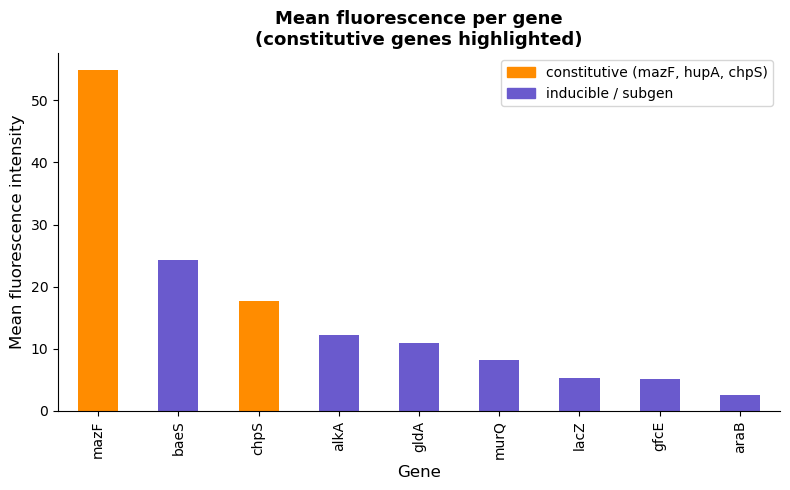

In [22]:

constitutive_genes = {'mazF', 'hupA', 'chpS'}

summary['constitutive'] = summary.index.isin(constitutive_genes)

mean_fluor_per_gene = df_g.groupby('gene')['intensity_mean_fluor'].mean().sort_values(ascending=False)
bar_colors = ['darkorange' if g in constitutive_genes else 'slateblue'
              for g in mean_fluor_per_gene.index]

fig, ax = plt.subplots(figsize=(8, 5))
mean_fluor_per_gene.plot.bar(ax=ax, color=bar_colors)
ax.set_xlabel('Gene', fontsize=12)
ax.set_ylabel('Mean fluorescence intensity', fontsize=12)
ax.set_title('Mean fluorescence per gene\n(constitutive genes highlighted)',
             fontsize=13, fontweight='bold')
ax.legend(handles=[
    Patch(color='darkorange', label='constitutive (mazF, hupA, chpS)'),
    Patch(color='slateblue', label='inducible / subgen'),
])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
